## 1 · Imports

In [1]:
# import scvelo as scv
from multiprocessing import Pool

import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

In [2]:
import mudata as mu

## 2 · Data Loading

Load mudata

In [3]:
mdata = mu.read_h5mu("001_create_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

## 3 · Metadata mapping

Load mudata

In [4]:
mapping = {
    "10mix_ICI1": "ctrl",
    "10mix_ICI2": "ctrl",
    "11mix_ICI1": "effector",
    "11mix_ICI2": "effector",
    "GF_ICI1": "GF_noici",
    "GF_ICI2": "GF_noici",
    "GF_ICI1_plus": "GF",
    "GF_ICI2_plus": "GF",
}

mdata["gex"].obs["group4"] = mdata["gex"].obs["sample_id"].map(mapping)

In [5]:
desired_order = [
    "effector",
    "ctrl",
    "GF",
    "GF_noici",
]

mdata["gex"].obs["group4"] = pd.Categorical(
    mdata["gex"].obs["group4"], categories=desired_order, ordered=True
)

## 4 · Gene marker ploting


In [6]:
import scanpy as sc


def plot_marker_umaps(adata, marker_dict, title_prefix):
    for category, genes in marker_dict.items():
        genes = sorted(list(genes))
        genes_present = [g for g in genes if g in adata.var_names]

        if len(genes_present) == 0:
            print(f"No genes found for {category}")
            continue

        print(f"Plotting {category}: {genes_present}")

        sc.pl.umap(
            adata,
            color=genes_present,
            ncols=4,
            cmap="Reds",
            vmax="p99",
            title=[f"{title_prefix} | {category} | {g}" for g in genes_present],
            frameon=False,
        )

In [7]:
gene_markers = {
    "Activated": {
        "Ccl5",
        "Ctla2a",
        "Cd44",
        "Tbx21",
    },
    "Cycling": {"Mki67", "Top2a", "Pclaf"},
    "Effector_memory": {"Gzmk", "Cxcr3"},
    "Exhausted": {
        "Tox",
    },
    "Stem/Resident_memory": {"Klf2", "Tcf7", "Foxp1", "Lef1", "Bach2", "Sell"},
}

In [8]:
gene_markers

{'Activated': {'Ccl5', 'Cd44', 'Ctla2a', 'Tbx21'},
 'Cycling': {'Mki67', 'Pclaf', 'Top2a'},
 'Effector_memory': {'Cxcr3', 'Gzmk'},
 'Exhausted': {'Tox'},
 'Stem/Resident_memory': {'Bach2', 'Foxp1', 'Klf2', 'Lef1', 'Sell', 'Tcf7'}}

Plotting Activated: ['Ccl5', 'Cd44', 'Ctla2a', 'Tbx21']


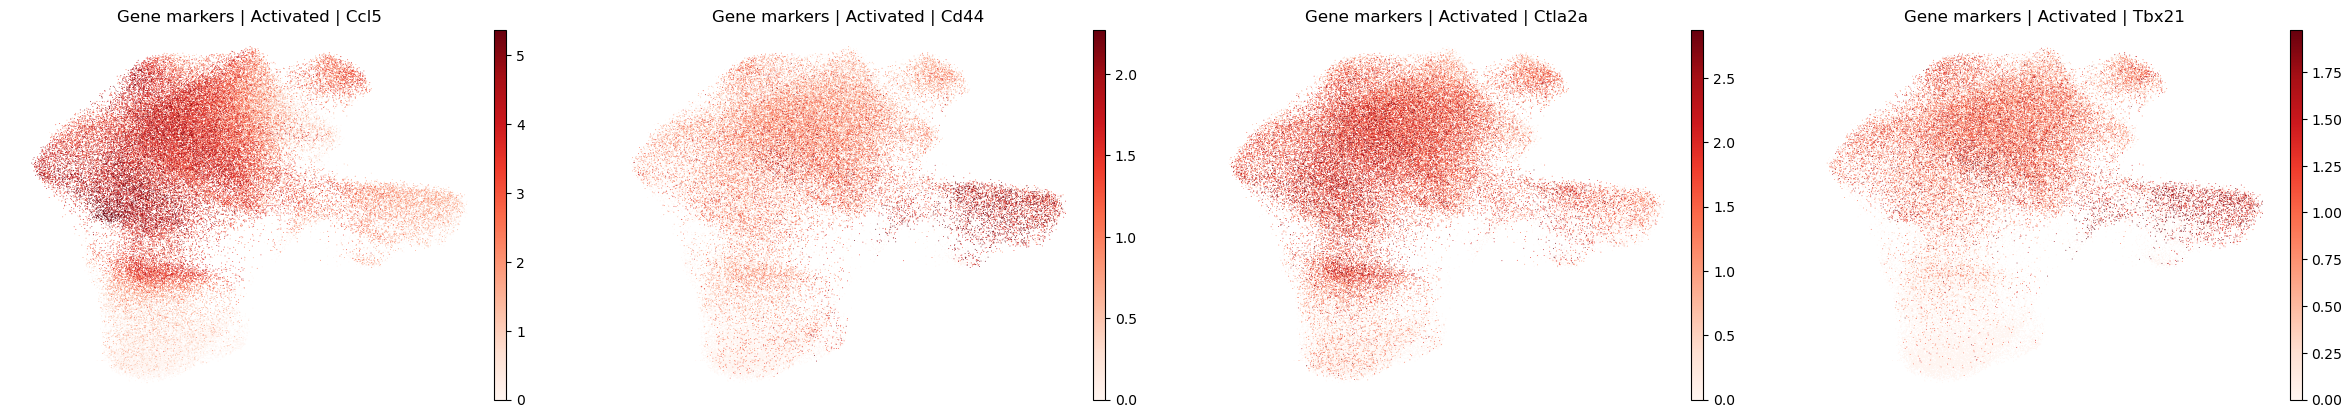

Plotting Cycling: ['Mki67', 'Pclaf', 'Top2a']


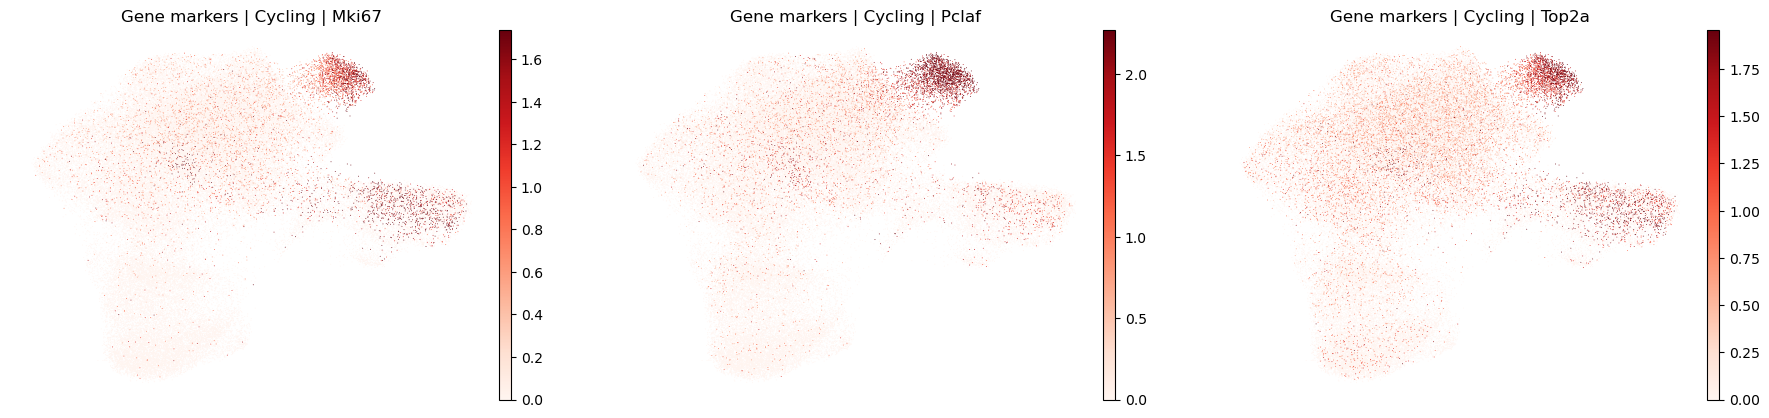

Plotting Effector_memory: ['Cxcr3', 'Gzmk']


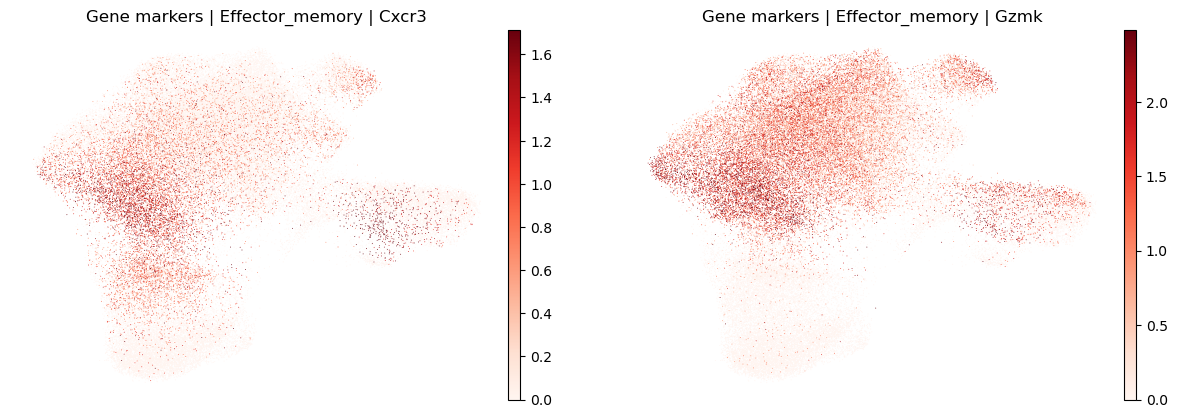

Plotting Exhausted: ['Tox']


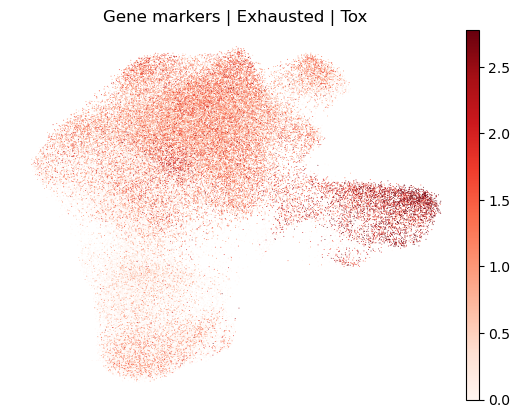

Plotting Stem/Resident_memory: ['Bach2', 'Foxp1', 'Klf2', 'Lef1', 'Sell', 'Tcf7']


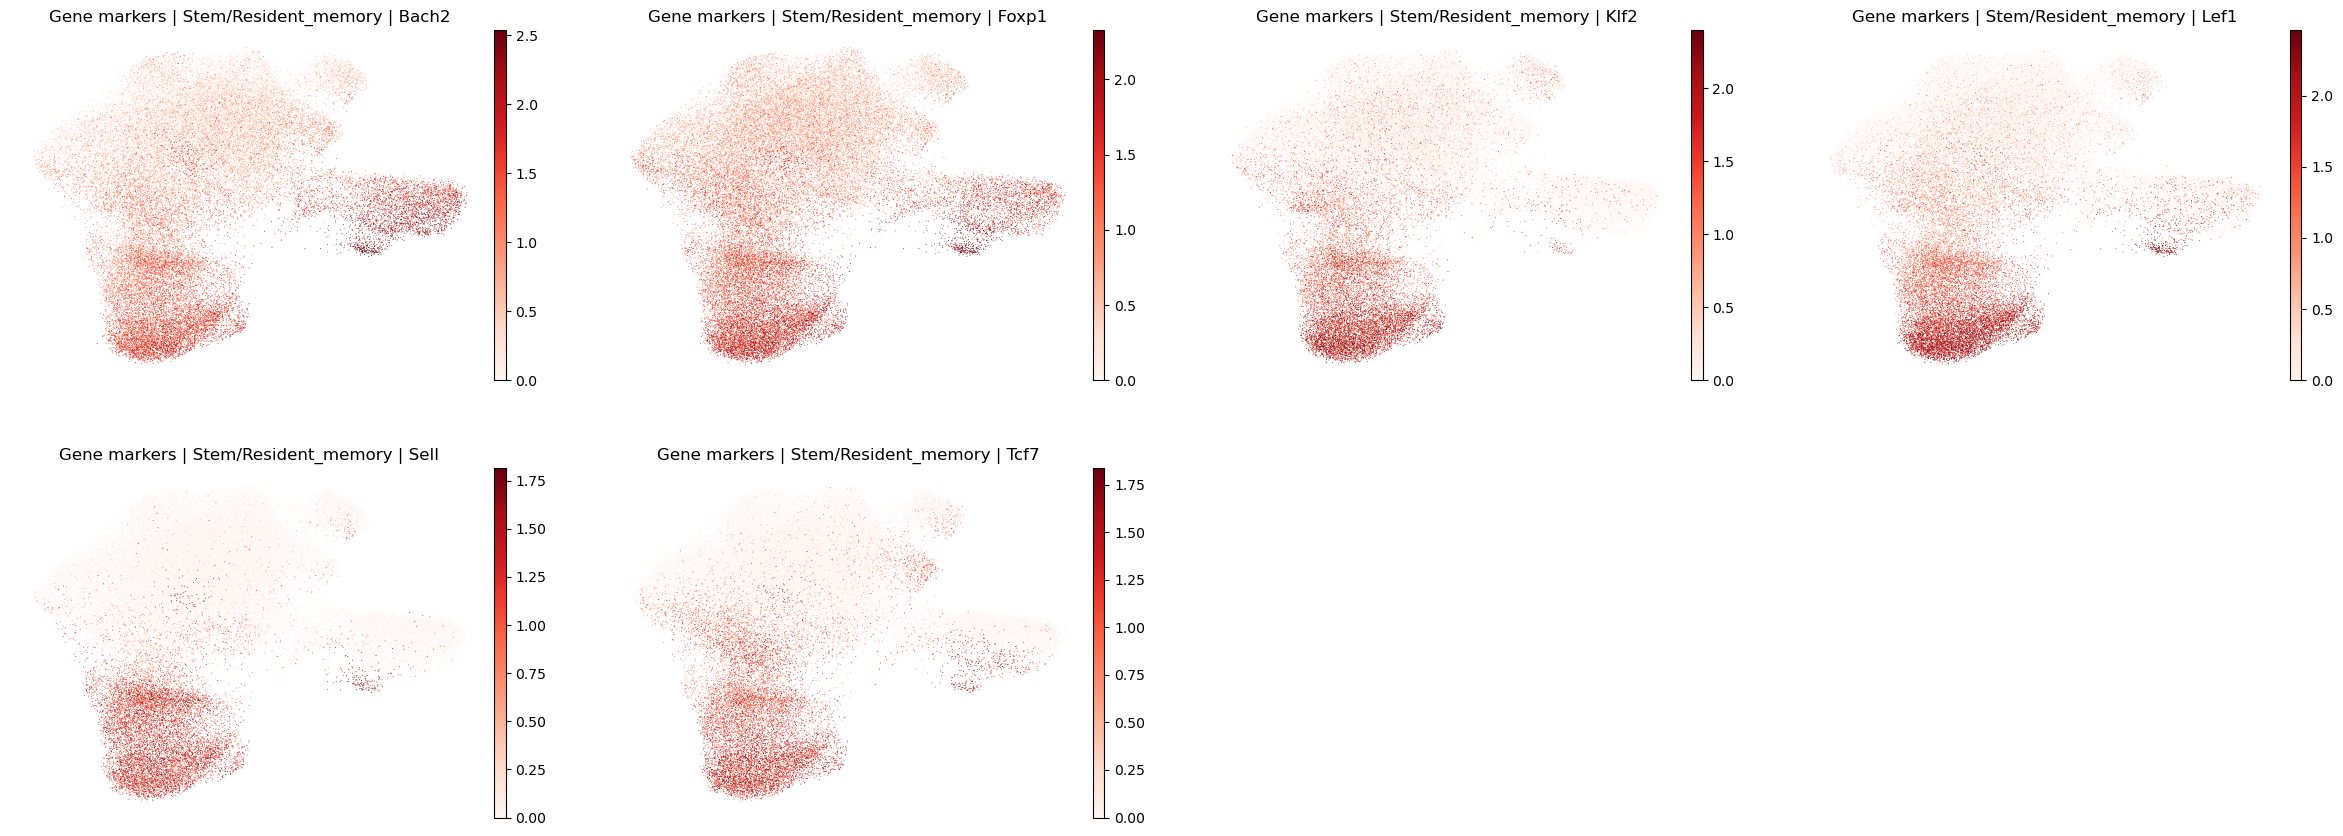

In [9]:
plot_marker_umaps(
    adata=mdata["gex"],
    marker_dict=gene_markers,title_prefix = "Gene markers"
)

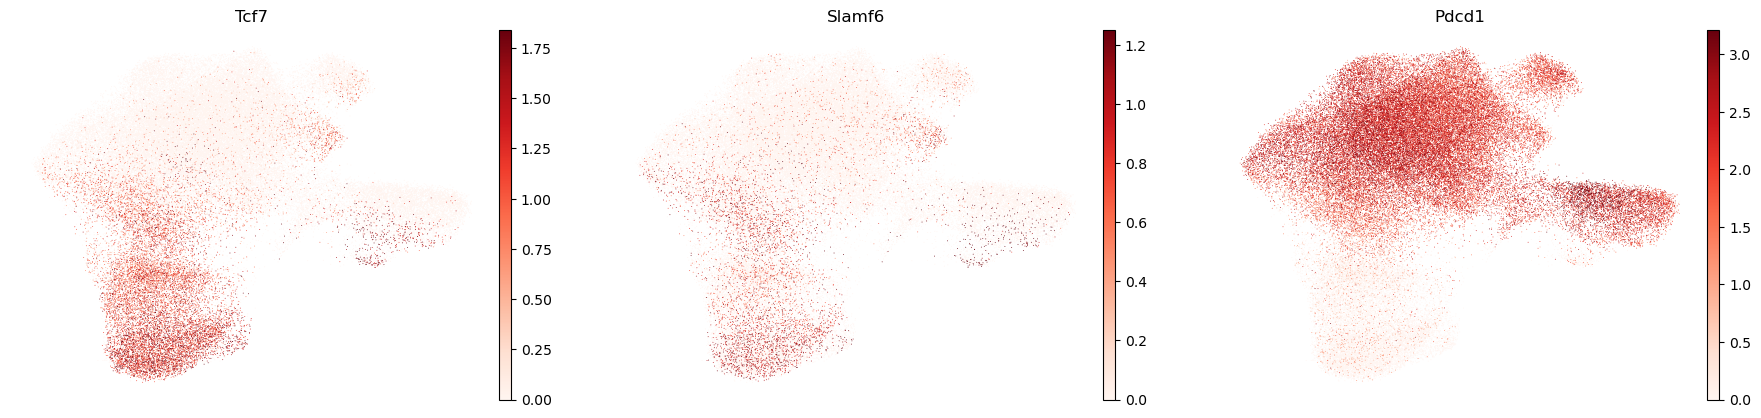

In [10]:
sc.pl.umap(
    mdata["gex"],
    color=["Tcf7", "Slamf6", "Pdcd1"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

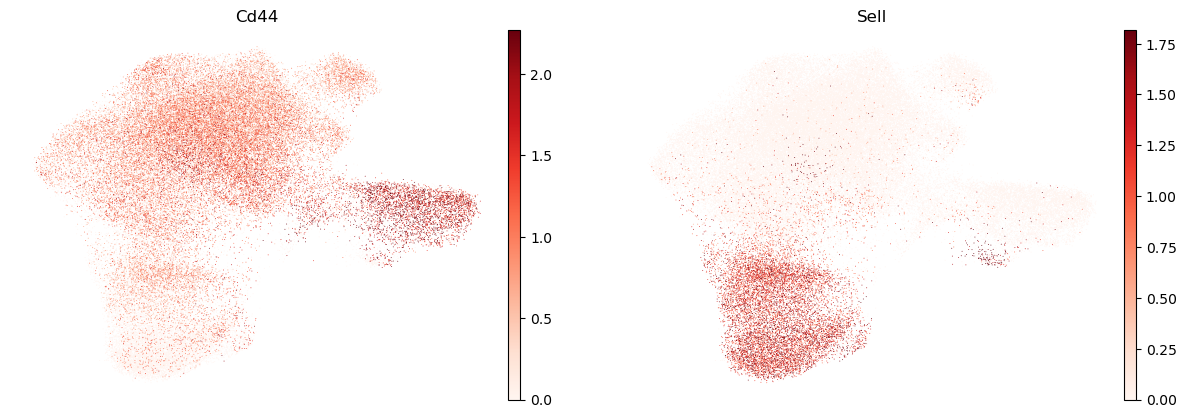

In [11]:
sc.pl.umap(
    mdata["gex"],
    color=["Cd44", "Sell"],
    ncols=4,
    cmap="Reds",
    vmax="p99",
    frameon=False,
)

## 5 · Annotation


In [12]:
# Check unique clusters first (optional, but recommended)
print(mdata["gex"].obs["rna_leiden_05"].unique())

# Create mapping dictionary (adjust numbers if needed)
cluster_annotation = {
    "0": "Activated",
    "1": "Stem/Resident_memory",
    "2": "Effector_memory",
    "3": "Stem/Resident_memory",
    "4": "Exhausted",
    "5": "Activated",
    "6": "Activated",
    "7": "Cycling",
}

# If gex03 is integer instead of string, remove the quotes in dictionary keys
# e.g., 0: "Activated"

# Create new annotation column
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["rna_leiden_05"].map(cluster_annotation)
)

# Make it categorical (recommended for plotting)
mdata["gex"].obs["cell_annotation_05"] = (
    mdata["gex"].obs["cell_annotation_05"].astype("category")
)

# Verify
print(mdata["gex"].obs[["rna_leiden_05", "cell_annotation_05"]].head())

['0', '2', '3', '1', '4', '7', '5', '6']
Categories (8, object): ['0', '1', '2', '3', '4', '5', '6', '7']
                              rna_leiden_05    cell_annotation_05
10mix-ICI1_AAACCTGAGAGCCTAG-1             0             Activated
10mix-ICI1_AAACCTGAGATGTGGC-1             2       Effector_memory
10mix-ICI1_AAACCTGAGCCACGTC-1             3  Stem/Resident_memory
10mix-ICI1_AAACCTGAGGCTCTTA-1             3  Stem/Resident_memory
10mix-ICI1_AAACCTGAGGGCACTA-1             2       Effector_memory


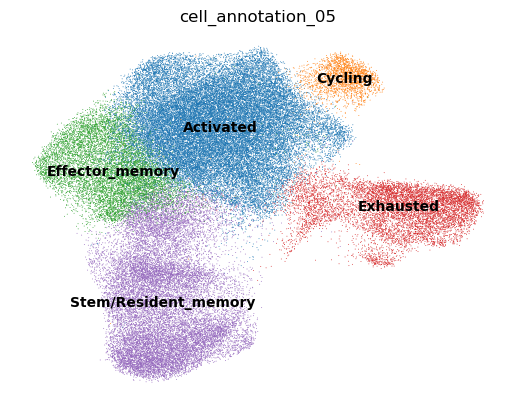

In [13]:
sc.pl.umap(
    mdata["gex"], color="cell_annotation_05", frameon=False, legend_loc="on data"
)

## 6 · Dotplot


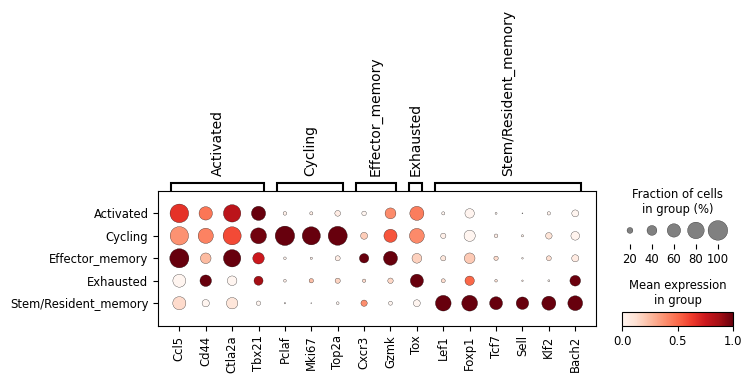

In [14]:
from matplotlib import cm


sc.pl.dotplot(
    mdata["gex"],
    gene_markers,
    groupby="cell_annotation_05",
    standard_scale="var",
    dendrogram=False,
    swap_axes=False,  # ,save="annotation.svg"
)

## 6 · Umap by sample


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

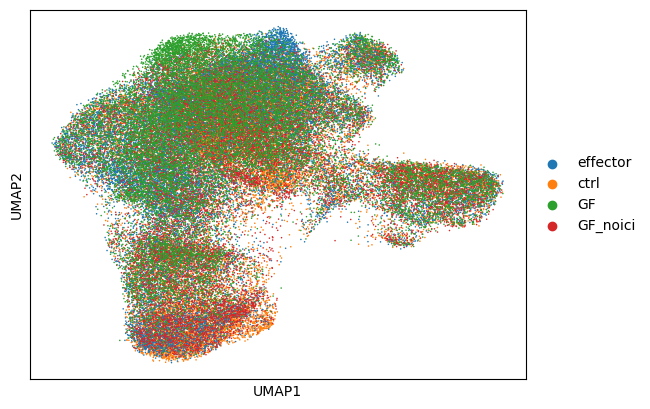

In [15]:
sc.pl.umap(
    mdata["gex"],
    color=["group4"],
    frameon=True,
    size=5,
    add_outline=False,
    # legend_loc="on data",
    title="",
    show=False,  # , save ="condition.png"
)

# plt.savefig("_condition.png", dpi=300, bbox_inches="tight")
# plt.close()

In [19]:
#mdata.write_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/002_annotate_mudata.h5mu")